# TCCT S91 - Locked Baseline and Ablation Benchmark

This is a post-hoc benchmark over the immutable 1,296-world S90 archive. It is not a new blind test. The S87D decoder is loaded by hash and is never trained, searched, retuned, or edited.

The benchmark compares the frozen decoder with the cached legacy K=33 policy, constant class baselines, and pre-registered frozen-input feature deletions. Feature deletions are sensitivity tests, not retrained ablation models.

Run **Kernel -> Restart Kernel and Run All Cells**. Expected runtime is a few minutes or less because propagation is not rerun.


In [898]:
ClearAll["Global`*"];
$HistoryLength=0;
<|"WolframVersion"->$Version,"SystemID"->$SystemID,
"ProcessorCount"->$ProcessorCount|>

<|WolframVersion -> 15.0.0 for Microsoft Windows (64-bit) (May 26, 2026), 
 
>   SystemID -> Windows-x86-64, ProcessorCount -> 10|>

Dataset[{<|Stage -> S91-PREFLIGHT, Passed -> True, ArchivedWorlds -> 1296, 
 
>     ContinueTargets -> 1152, StopTargets -> 144, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CoreLoaded -> False, TrainingRun -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Passed, ArchivedWorlds, ContinueTargets, 
 
>      StopTargets, CandidateHash, CoreLoaded, TrainingRun}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
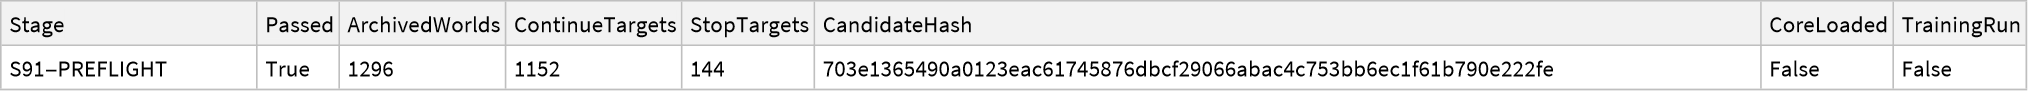

In [905]:
ClearAll[FileSHA256Hex91];
FileSHA256Hex91[path_String]:=IntegerString[FileHash[path,"SHA256"],16,64];

projectDirectory91=Directory[];
archivePath91=FileNameJoin[{projectDirectory91,"artifacts",
"TCCT_S90_BenchmarkWorlds.json"}];
archiveManifestPath91=FileNameJoin[{projectDirectory91,"artifacts",
"TCCT_S90_BenchmarkWorlds_Manifest.json"}];
decoderRuntimePath91="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
decoderCandidatePath91="E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
s90CertificatePath91="E:/engine_wolf/TCCT_S90_BlindResultCertificate.json";
s91CertificatePath="E:/engine_wolf/TCCT_S91_BenchmarkCertificate.json";

expectedArchiveFileHash91=
"39b1b822153e33e01d0294168507c06a8c6c96726f7a875394026d257603f0c0";
expectedArchiveManifestFileHash91=
"9e948cc950cd638eae1aaebcf40496280361c5d6ffd3bb6a48bb879539858a24";
expectedArchivePayloadHash91=
"b7867e7f1deab9584f89349bd08d1d9a4b08b69a5790c3d7527a7178cb30f10b";
expectedDecoderCandidateFileHash91=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedDecoderCandidateHash91=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedDecoderRuntimeFileHash91=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedS90CertificateFileHash91=
"0e8c9df9e63ea68d59226416de33243440ef4b84a007be0812b2970ed53deb30";
expectedS90ProtocolHash91=
"ed241ba2ada54af6e44f9dc009a70f4155767de6994072c7c05e5b75515df518";
expectedS90TestDefinitionHash91=
"ef31b96fa3a1ff1b4c7f4aec17456d60ec3381eca4df7f6ee8b9bf25f320539c";

requiredFiles91={archivePath91,archiveManifestPath91,decoderRuntimePath91,
decoderCandidatePath91,s90CertificatePath91};
If[!And@@(FileExistsQ/@requiredFiles91),
Print["S91 aborted: one or more locked input files are missing."];
Dataset[AssociationThread[requiredFiles91,FileExistsQ/@requiredFiles91]];
Abort[]];
If[FileExistsQ[s91CertificatePath],
Print["S91 aborted: a prior benchmark certificate already exists. Preserve it."];
Print[s91CertificatePath];Abort[]];

archiveFileHashBefore91=FileSHA256Hex91[archivePath91];
archiveManifestFileHashBefore91=FileSHA256Hex91[archiveManifestPath91];
decoderCandidateFileHashBefore91=FileSHA256Hex91[decoderCandidatePath91];
decoderRuntimeFileHashBefore91=FileSHA256Hex91[decoderRuntimePath91];
s90CertificateFileHashBefore91=FileSHA256Hex91[s90CertificatePath91];

archive91=Quiet@Check[Import[archivePath91,"RawJSON"],$Failed];
archiveManifest91=Quiet@Check[Import[archiveManifestPath91,"RawJSON"],$Failed];
s90Certificate91=Quiet@Check[Import[s90CertificatePath91,"RawJSON"],$Failed];
If[!AssociationQ[archive91]||!AssociationQ[archiveManifest91]||
!AssociationQ[s90Certificate91],
Print["S91 aborted: a locked JSON input could not be imported."];Abort[]];

Get[decoderRuntimePath91];
decoder91=Quiet@Check[TCCTLoadFrozenDecoderS87D[decoderCandidatePath91],$Failed];
If[!AssociationQ[decoder91],
Print["S91 aborted: the frozen S87D decoder failed its internal hash checks."];
Abort[]];

rows91=Lookup[archive91,"Rows",$Failed];
vectors91=If[ListQ[rows91],Lookup[rows91,"FeatureVector",$Failed],$Failed];
targets91=If[ListQ[rows91],Lookup[rows91,"Target",$Failed],$Failed];
cachedFullPredictions91=If[ListQ[rows91],Lookup[rows91,"Prediction",$Failed],$Failed];
cachedLegacyPredictions91=If[ListQ[rows91],Lookup[rows91,"LegacyPrediction",$Failed],$Failed];
classifier91=Lookup[decoder91,"Classifier",$Failed];

preflightPassed91=And[
SameQ[archiveFileHashBefore91,expectedArchiveFileHash91],
SameQ[archiveManifestFileHashBefore91,expectedArchiveManifestFileHash91],
SameQ[decoderCandidateFileHashBefore91,expectedDecoderCandidateFileHash91],
SameQ[decoderRuntimeFileHashBefore91,expectedDecoderRuntimeFileHash91],
SameQ[s90CertificateFileHashBefore91,expectedS90CertificateFileHash91],
SameQ[Lookup[archive91,"ArchivePayloadHash",Missing[]],expectedArchivePayloadHash91],
SameQ[Lookup[archiveManifest91,"ArchivePayloadHash",Missing[]],expectedArchivePayloadHash91],
SameQ[Lookup[archive91,"SourceProtocolHash",Missing[]],expectedS90ProtocolHash91],
SameQ[Lookup[archive91,"SourceTestDefinitionHash",Missing[]],
expectedS90TestDefinitionHash91],
SameQ[Lookup[s90Certificate91,"ProtocolHash",Missing[]],expectedS90ProtocolHash91],
SameQ[Lookup[s90Certificate91,"TestDefinitionHash",Missing[]],
expectedS90TestDefinitionHash91],
SameQ[Lookup[s90Certificate91,"Outcome",Missing[]],
"S90_BLIND_INTERVENTION_ALGEBRA_PASS"],
SameQ[Lookup[decoder91,"CandidateHash",Missing[]],expectedDecoderCandidateHash91],
SameQ[Lookup[archive91,"SourceCandidateHash",Missing[]],expectedDecoderCandidateHash91],
ListQ[rows91],SameQ[Length[rows91],1296],
ListQ[vectors91],SameQ[Length[vectors91],1296],
And@@(VectorQ[#,IntegerQ]&&Length[#]===27&/@vectors91),
SameQ[Counts[targets91],<|"Stop"->144,"Continue"->1152|>],
And@@(MemberQ[{"Continue","Stop"},#]&/@cachedFullPredictions91),
And@@(MemberQ[{"Continue","Stop"},#]&/@cachedLegacyPredictions91),
Head[classifier91]===ClassifierFunction
];
If[!TrueQ[preflightPassed91],
Print["S91 aborted: locked-input preflight failed."];Abort[]];

Dataset[{<|"Stage"->"S91-PREFLIGHT","Passed"->preflightPassed91,
"ArchivedWorlds"->Length[rows91],"ContinueTargets"->Count[targets91,"Continue"],
"StopTargets"->Count[targets91,"Stop"],
"CandidateHash"->decoder91["CandidateHash"],
"CoreLoaded"->False,"TrainingRun"->False|>}]

Dataset[{<|Stage -> S91, Name -> BaselineAblationBenchmark, 
 
>     EvaluationType -> PostHocLockedS90Benchmark, BlindTest -> False, 
 
>     S90ResultsAlreadyRevealed -> True, 
 
>     BenchmarkArchiveHash -> 
 
>      39b1b822153e33e01d0294168507c06a8c6c96726f7a875394026d257603f0c0, 
 
>     BenchmarkArchivePayloadHash -> 
 
>      b7867e7f1deab9584f89349bd08d1d9a4b08b69a5790c3d7527a7178cb30f10b, 
 
>     SourceS90ProtocolHash -> 
 
>      ed241ba2ada54af6e44f9dc009a70f4155767de6994072c7c05e5b75515df518, 
 
>     SourceS90TestDefinitionHash -> 
 
>      ef31b96fa3a1ff1b4c7f4aec17456d60ec3381eca4df7f6ee8b9bf25f320539c, 
 
>     FrozenCandidateHash -> 
 
>      703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     Models -> {<|Model -> FrozenS87DFull, Kind -> FrozenDecoder, 
 
>        Transform -> Identity, Positions -> {}|>, 
 
>       <|Model -> LegacyK33ExactRole, Kind -> CachedBaseline, 
 
>        Transform -> CachedLegacyPrediction, Positions -> {}|>, 
 
>       <|Model -> AlwaysContinue, Kind -> ConstantBaseline, 
 
>        Transform -> ConstantContinue, Positions -> {}|>, 
 
>       <|Model -> AlwaysStop, Kind -> ConstantBaseline, Transform -> ConstantStop, 
 
>        Positions -> {}|>, <|Model -> DropPairwiseStatistics, 
 
>        Kind -> FrozenFeatureAblation, Transform -> Drop, 
 
>        Positions -> {18, 19, 20, 21, 22, 23, 24, 25, 26, 27}|>, 
 
>       <|Model -> DropUnaryCodeStatistics, Kind -> FrozenFeatureAblation, 
 
>        Transform -> Drop, Positions -> 
 
>         {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17}|>, 
 
>       <|Model -> DropModuloArithmetic, Kind -> FrozenFeatureAblation, 
 
>        Transform -> Drop, Positions -> {11, 12, 13}|>, 
 
>       <|Model -> DropCoordinateMoments, Kind -> FrozenFeatureAblation, 
 
>        Transform -> Drop, Positions -> {3, 4, 5, 6, 7, 8, 9, 10}|>, 
 
>       <|Model -> DropOrderAndDistance, Kind -> FrozenFeatureAblation, 
 
>        Transform -> Drop, Positions -> {14, 15, 16, 17}|>, 
 
>       <|Model -> DropCardinality, Kind -> FrozenFeatureAblation, Transform -> Drop, 
 
>        Positions -> {1, 2, 18}|>, 
 
>       <|Model -> KeepOnlyModuloArithmetic, Kind -> FrozenFeatureAblation, 
 
>        Transform -> Keep, Positions -> {1, 2, 11, 12, 13, 18}|>, 
 
>       <|Model -> KeepOnlyCoordinateMoments, Kind -> FrozenFeatureAblation, 
 
>        Transform -> Keep, Positions -> {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 18}|>, 
 
>       <|Model -> KeepOnlyOrderAndDistance, Kind -> FrozenFeatureAblation, 
 
>        Transform -> Keep, Positions -> {1, 2, 14, 15, 16, 17, 18}|>, 
 
>       <|Model -> KeepOnlyPairwiseStatistics, Kind -> FrozenFeatureAblation, 
 
>        Transform -> Keep, Positions -> {1, 2, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27}|>
 
>        }, AblationType -> FrozenInputSensitivityWithoutRetraining, 
 
>     AllTrainableParametersFrozen -> True, TransformInputs -> {FeatureVector}, 
 
>     TransformUsesTargets -> False, NoS88S89S90LabelUsedForTraining -> True, 
 
>     TrainingRun -> False, CandidateSearchRun -> False, 
 
>     HyperparameterSearchRun -> False, RetuningApplied -> False, CoreLoaded -> False, 
 
>     CoreEditApplied -> False, OriginalFrozenPolicyEditApplied -> False, 
 
>     DeduplicationMechanismEditApplied -> False, CanonicalizerEditApplied -> False, 
 
>     InterventionRuleEditApplied -> False, 
 
>     TimingScope -> DecoderOnlyOnCachedS90FeatureVectors, 
 
>     TransformDefinitionHash -> 
 
>      b28a5664c414eaaec00536395800e3a4909577bf672614aa9caa41522cdcc81e, 
 
>     ProtocolHash -> 815c367c88a669939a9361553415d6396333be7e976d72f0ca5dbc0ea692ff1b|>}
 
>    , TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 
 
>     29], 1], <||>]
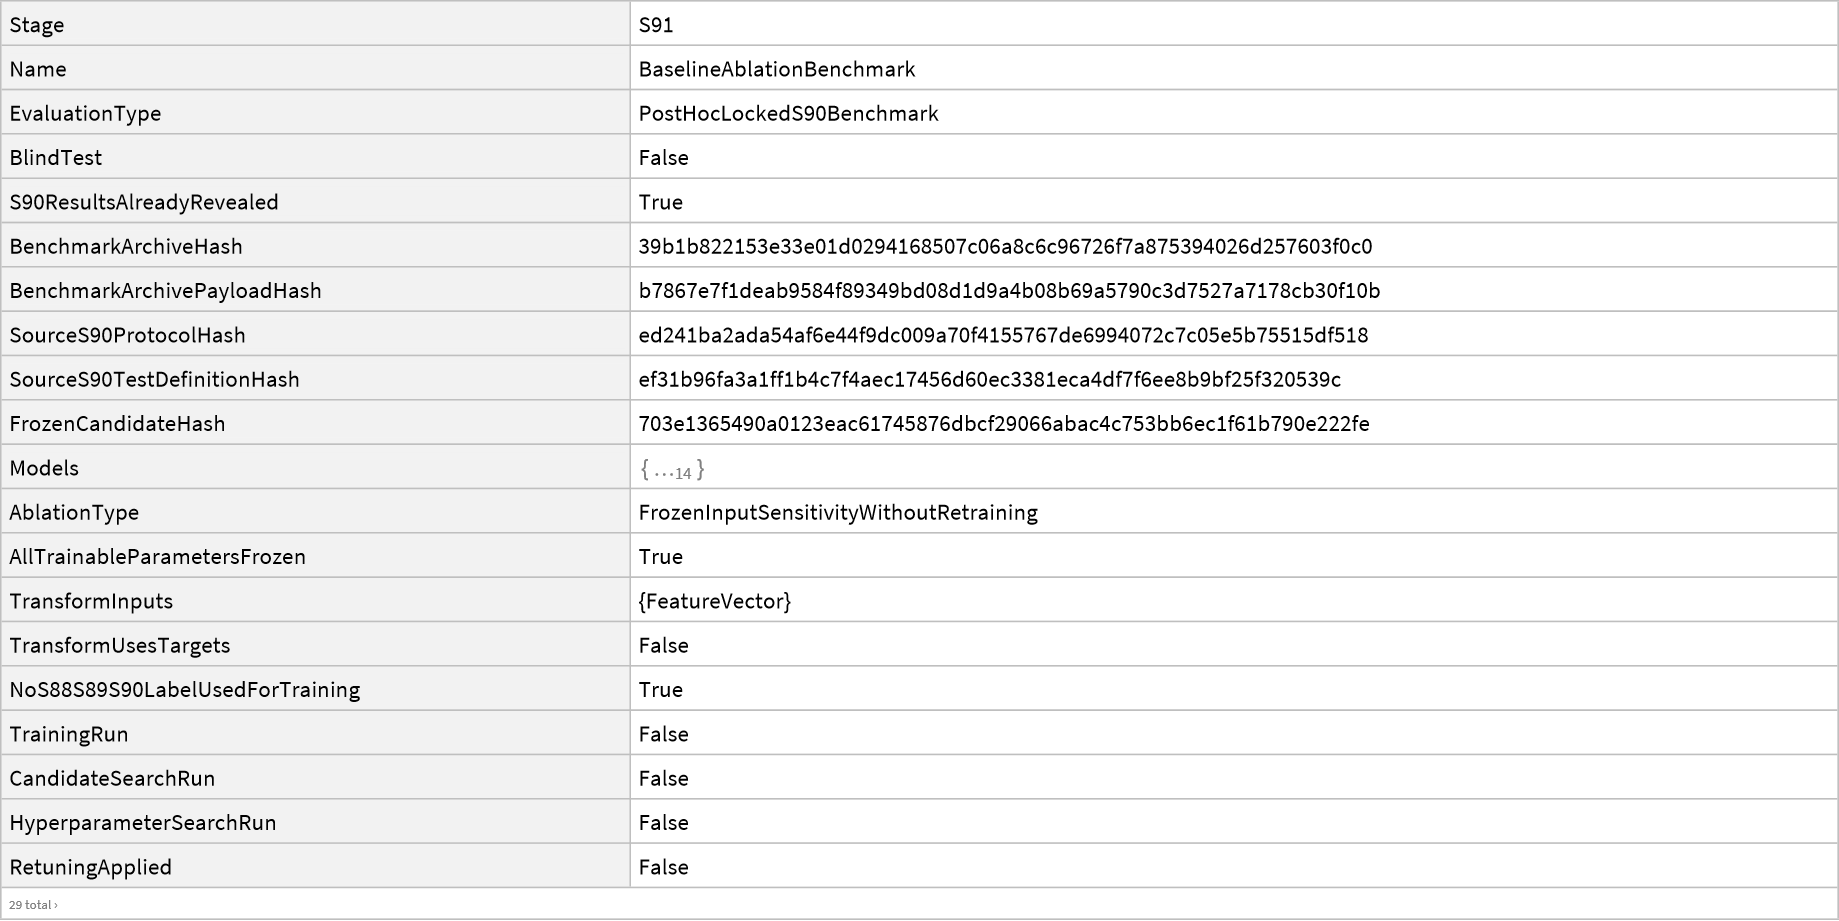

In [951]:
ClearAll[ZeroPositions91,KeepPositions91,TransformVector91,
ScorePredictions91,PredictionBundle91,ResultRow91,GroupedRows91];

ZeroPositions91[vector_List,positions_List]:=ReplacePart[
vector,Thread[positions->0]];
KeepPositions91[vector_List,positions_List]:=ZeroPositions91[
vector,Complement[Range[Length[vector]],positions]];
TransformVector91[vector_List,mode_String,positions_List]:=Switch[mode,
"Identity",vector,
"Drop",ZeroPositions91[vector,positions],
"Keep",KeepPositions91[vector,positions],
_,$Failed];

modelSpecs91={
<|"Model"->"FrozenS87DFull","Kind"->"FrozenDecoder",
"Transform"->"Identity","Positions"->{}|>,
<|"Model"->"LegacyK33ExactRole","Kind"->"CachedBaseline",
"Transform"->"CachedLegacyPrediction","Positions"->{}|>,
<|"Model"->"AlwaysContinue","Kind"->"ConstantBaseline",
"Transform"->"ConstantContinue","Positions"->{}|>,
<|"Model"->"AlwaysStop","Kind"->"ConstantBaseline",
"Transform"->"ConstantStop","Positions"->{}|>,
<|"Model"->"DropPairwiseStatistics","Kind"->"FrozenFeatureAblation",
"Transform"->"Drop","Positions"->Range[18,27]|>,
<|"Model"->"DropUnaryCodeStatistics","Kind"->"FrozenFeatureAblation",
"Transform"->"Drop","Positions"->Range[1,17]|>,
<|"Model"->"DropModuloArithmetic","Kind"->"FrozenFeatureAblation",
"Transform"->"Drop","Positions"->{11,12,13}|>,
<|"Model"->"DropCoordinateMoments","Kind"->"FrozenFeatureAblation",
"Transform"->"Drop","Positions"->Range[3,10]|>,
<|"Model"->"DropOrderAndDistance","Kind"->"FrozenFeatureAblation",
"Transform"->"Drop","Positions"->Range[14,17]|>,
<|"Model"->"DropCardinality","Kind"->"FrozenFeatureAblation",
"Transform"->"Drop","Positions"->{1,2,18}|>,
<|"Model"->"KeepOnlyModuloArithmetic","Kind"->"FrozenFeatureAblation",
"Transform"->"Keep","Positions"->{1,2,11,12,13,18}|>,
<|"Model"->"KeepOnlyCoordinateMoments","Kind"->"FrozenFeatureAblation",
"Transform"->"Keep","Positions"->Join[{1,2},Range[3,10],{18}]|>,
<|"Model"->"KeepOnlyOrderAndDistance","Kind"->"FrozenFeatureAblation",
"Transform"->"Keep","Positions"->Join[{1,2},Range[14,18]]|>,
<|"Model"->"KeepOnlyPairwiseStatistics","Kind"->"FrozenFeatureAblation",
"Transform"->"Keep","Positions"->Join[{1,2},Range[18,27]]|>
};

transformDefinitionHashBeforeScoring91=Hash[{
DownValues[ZeroPositions91],DownValues[KeepPositions91],
DownValues[TransformVector91],Normal[modelSpecs91]},"SHA256","HexString"];

protocol91=<|
"Stage"->"S91","Name"->"BaselineAblationBenchmark",
"EvaluationType"->"PostHocLockedS90Benchmark",
"BlindTest"->False,"S90ResultsAlreadyRevealed"->True,
"BenchmarkArchiveHash"->expectedArchiveFileHash91,
"BenchmarkArchivePayloadHash"->expectedArchivePayloadHash91,
"SourceS90ProtocolHash"->expectedS90ProtocolHash91,
"SourceS90TestDefinitionHash"->expectedS90TestDefinitionHash91,
"FrozenCandidateHash"->expectedDecoderCandidateHash91,
"Models"->modelSpecs91,
"AblationType"->"FrozenInputSensitivityWithoutRetraining",
"AllTrainableParametersFrozen"->True,
"TransformInputs"->{"FeatureVector"},
"TransformUsesTargets"->False,
"NoS88S89S90LabelUsedForTraining"->True,
"TrainingRun"->False,"CandidateSearchRun"->False,
"HyperparameterSearchRun"->False,"RetuningApplied"->False,
"CoreLoaded"->False,"CoreEditApplied"->False,
"OriginalFrozenPolicyEditApplied"->False,
"DeduplicationMechanismEditApplied"->False,
"CanonicalizerEditApplied"->False,
"InterventionRuleEditApplied"->False,
"TimingScope"->"DecoderOnlyOnCachedS90FeatureVectors",
"TransformDefinitionHash"->transformDefinitionHashBeforeScoring91
|>;
protocolHashBeforeScoring91=Hash[Normal[protocol91],"SHA256","HexString"];
Dataset[{Append[protocol91,"ProtocolHash"->protocolHashBeforeScoring91]}]

Dataset[{<|Model -> FrozenS87DFull, Kind -> FrozenDecoder, Transform -> Identity, 
 
>     Positions -> {}, Score -> 1296, Cases -> 1296, Accuracy -> 1., 
 
>     ContinueCorrect -> 1152, ContinueCases -> 1152, ContinueAccuracy -> 1., 
 
>     StopCorrect -> 144, StopCases -> 144, StopAccuracy -> 1., BalancedAccuracy -> 1., 
 
>     InvalidPredictions -> 0, ChangedVsFull -> 0, DecoderSeconds -> 18.4473, 
 
>     AccuracyGapFromFull -> 0.|>, <|Model -> LegacyK33ExactRole, 
 
>     Kind -> CachedBaseline, Transform -> CachedLegacyPrediction, Positions -> {}, 
 
>     Score -> 128, Cases -> 1296, Accuracy -> 0.0987654, ContinueCorrect -> 0, 
 
>     ContinueCases -> 1152, ContinueAccuracy -> 0., StopCorrect -> 128, 
 
>     StopCases -> 144, StopAccuracy -> 0.888889, BalancedAccuracy -> 0.444444, 
 
>     InvalidPredictions -> 0, ChangedVsFull -> 1168, 
 
>     DecoderSeconds -> NotMeasuredCached, AccuracyGapFromFull -> 0.901235|>, 
 
>    <|Model -> AlwaysContinue, Kind -> ConstantBaseline, Transform -> ConstantContinue, 
 
>     Positions -> {}, Score -> 1152, Cases -> 1296, Accuracy -> 0.888889, 
 
>     ContinueCorrect -> 1152, ContinueCases -> 1152, ContinueAccuracy -> 1., 
 
>     StopCorrect -> 0, StopCases -> 144, StopAccuracy -> 0., BalancedAccuracy -> 0.5, 
 
>     InvalidPredictions -> 0, ChangedVsFull -> 144, 
 
>     DecoderSeconds -> NotMeasuredConstant, AccuracyGapFromFull -> 0.111111|>, 
 
>    <|Model -> AlwaysStop, Kind -> ConstantBaseline, Transform -> ConstantStop, 
 
>     Positions -> {}, Score -> 144, Cases -> 1296, Accuracy -> 0.111111, 
 
>     ContinueCorrect -> 0, ContinueCases -> 1152, ContinueAccuracy -> 0., 
 
>     StopCorrect -> 144, StopCases -> 144, StopAccuracy -> 1., BalancedAccuracy -> 0.5, 
 
>     InvalidPredictions -> 0, ChangedVsFull -> 1152, 
 
>     DecoderSeconds -> NotMeasuredConstant, AccuracyGapFromFull -> 0.888889|>, 
 
>    <|Model -> DropPairwiseStatistics, Kind -> FrozenFeatureAblation, 
 
>     Transform -> Drop, Positions -> {18, 19, 20, 21, 22, 23, 24, 25, 26, 27}, 
 
>     Score -> 1296, Cases -> 1296, Accuracy -> 1., ContinueCorrect -> 1152, 
 
>     ContinueCases -> 1152, ContinueAccuracy -> 1., StopCorrect -> 144, 
 
>     StopCases -> 144, StopAccuracy -> 1., BalancedAccuracy -> 1., 
 
>     InvalidPredictions -> 0, ChangedVsFull -> 0, DecoderSeconds -> 16.1866, 
 
>     AccuracyGapFromFull -> 0.|>, <|Model -> DropUnaryCodeStatistics, 
 
>     Kind -> FrozenFeatureAblation, Transform -> Drop, 
 
>     Positions -> {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, 
 
>     Score -> 1152, Cases -> 1296, Accuracy -> 0.888889, ContinueCorrect -> 1152, 
 
>     ContinueCases -> 1152, ContinueAccuracy -> 1., StopCorrect -> 0, StopCases -> 144, 
 
>     StopAccuracy -> 0., BalancedAccuracy -> 0.5, InvalidPredictions -> 0, 
 
>     ChangedVsFull -> 144, DecoderSeconds -> 18.5623, AccuracyGapFromFull -> 0.111111|>\
 
>     , <|Model -> DropModuloArithmetic, Kind -> FrozenFeatureAblation, 
 
>     Transform -> Drop, Positions -> {11, 12, 13}, Score -> 1296, Cases -> 1296, 
 
>     Accuracy -> 1., ContinueCorrect -> 1152, ContinueCases -> 1152, 
 
>     ContinueAccuracy -> 1., StopCorrect -> 144, StopCases -> 144, StopAccuracy -> 1., 
 
>     BalancedAccuracy -> 1., InvalidPredictions -> 0, ChangedVsFull -> 0, 
 
>     DecoderSeconds -> 18.859, AccuracyGapFromFull -> 0.|>, 
 
>    <|Model -> DropCoordinateMoments, Kind -> FrozenFeatureAblation, Transform -> Drop, 
 
>     Positions -> {3, 4, 5, 6, 7, 8, 9, 10}, Score -> 1296, Cases -> 1296, 
 
>     Accuracy -> 1., ContinueCorrect -> 1152, ContinueCases -> 1152, 
 
>     ContinueAccuracy -> 1., StopCorrect -> 144, StopCases -> 144, StopAccuracy -> 1., 
 
>     BalancedAccuracy -> 1., InvalidPredictions -> 0, ChangedVsFull -> 0, 
 
>     DecoderSeconds -> 14.8058, AccuracyGapFromFull -> 0.|>, 
 
>    <|Model -> DropOrderAndDistance, Kind -> FrozenFeatureAblation, Transform -> Drop, 
 
>     Positions -> {14, 15, 16, 17}, S
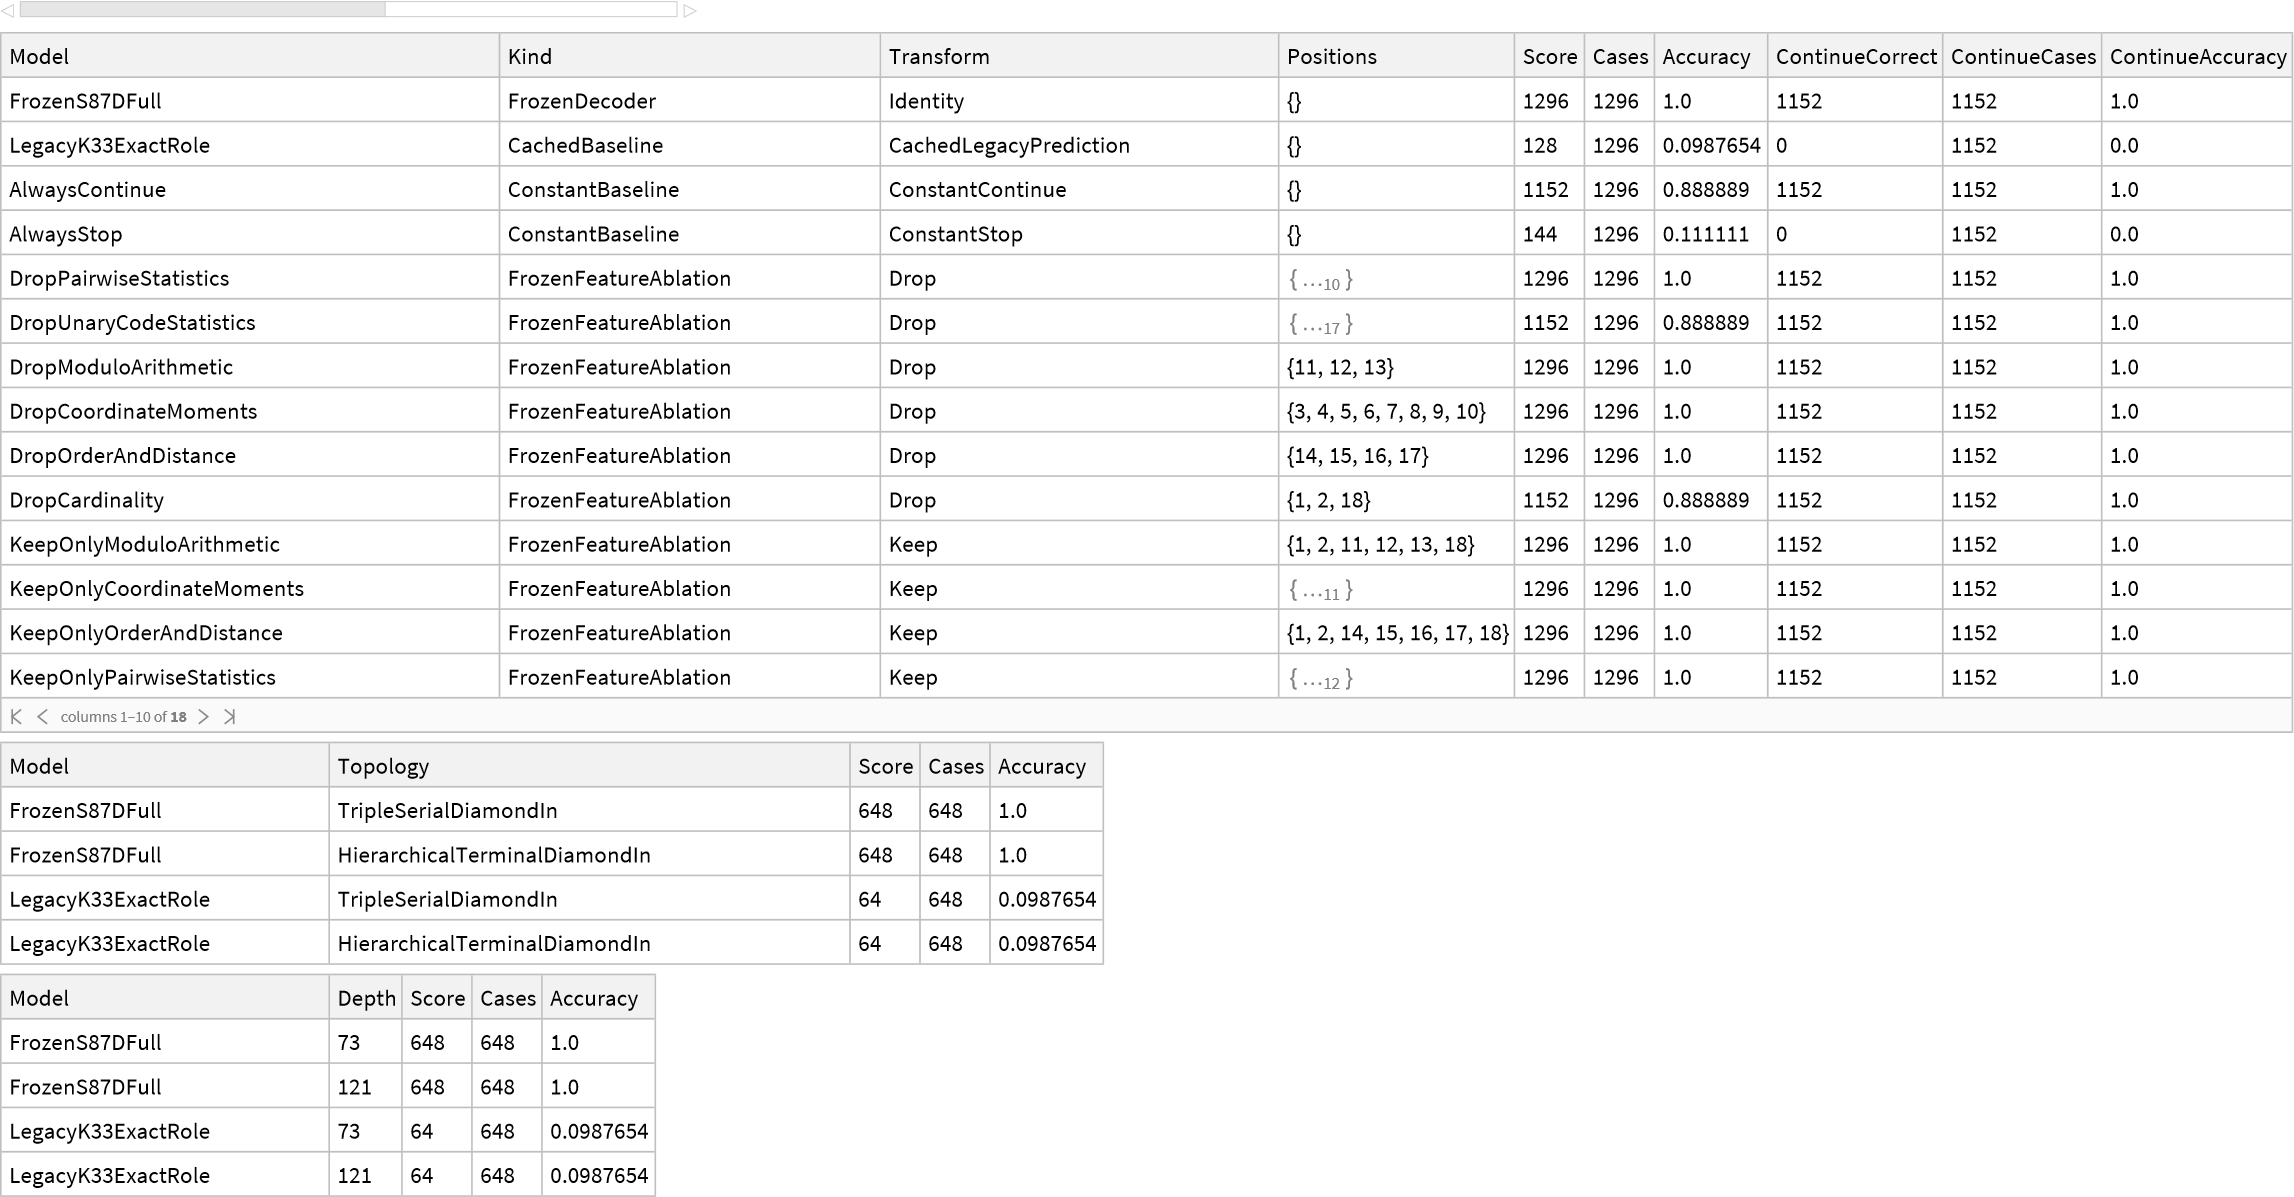

In [964]:
PredictionBundle91[spec_Association]:=Module[
{kind,mode,positions,transformed,timed,predictions,seconds},
kind=spec["Kind"];mode=spec["Transform"];positions=spec["Positions"];
Switch[kind,
"FrozenDecoder"|"FrozenFeatureAblation",
transformed=TransformVector91[#,mode,positions]&/@vectors91;
timed=AbsoluteTiming[Quiet@Check[classifier91/@transformed,$Failed]];
seconds=N[timed[[1]]];predictions=timed[[2]],
"CachedBaseline",predictions=cachedLegacyPredictions91;seconds="NotMeasuredCached",
"ConstantBaseline",predictions=If[SameQ[mode,"ConstantContinue"],
ConstantArray["Continue",Length[targets91]],ConstantArray["Stop",Length[targets91]]];
seconds="NotMeasuredConstant",
_,predictions=$Failed;seconds="Invalid"];
<|"Spec"->spec,"Predictions"->predictions,"DecoderSeconds"->seconds|>
];

predictionBundles91=PredictionBundle91/@modelSpecs91;
freshFullPredictions91=Lookup[First[predictionBundles91],"Predictions",$Failed];
freshFullMatchesCachedS9091=SameQ[freshFullPredictions91,cachedFullPredictions91];

ScorePredictions91[predictions_List]:=Module[
{continuePositions,stopPositions,continueCorrect,stopCorrect,score,invalid},
continuePositions=Flatten@Position[targets91,"Continue"];
stopPositions=Flatten@Position[targets91,"Stop"];
continueCorrect=Count[predictions[[continuePositions]],"Continue"];
stopCorrect=Count[predictions[[stopPositions]],"Stop"];
score=Count[MapThread[SameQ,{predictions,targets91}],True];
invalid=Count[predictions,x_/;!MemberQ[{"Continue","Stop"},x]];
<|"Score"->score,"Cases"->Length[targets91],
"Accuracy"->N[score/Length[targets91]],
"ContinueCorrect"->continueCorrect,"ContinueCases"->Length[continuePositions],
"ContinueAccuracy"->N[continueCorrect/Length[continuePositions]],
"StopCorrect"->stopCorrect,"StopCases"->Length[stopPositions],
"StopAccuracy"->N[stopCorrect/Length[stopPositions]],
"BalancedAccuracy"->N@Mean[{continueCorrect/Length[continuePositions],
stopCorrect/Length[stopPositions]}],"InvalidPredictions"->invalid|>
];

ResultRow91[bundle_Association]:=Module[{spec,predictions,score,changed},
spec=bundle["Spec"];predictions=bundle["Predictions"];
If[!ListQ[predictions]||!SameQ[Length[predictions],Length[targets91]],
Return[Join[spec,<|"Score"->0,"Cases"->Length[targets91],
"Accuracy"->0.,"BalancedAccuracy"->0.,"InvalidPredictions"->Length[targets91],
"ChangedVsFull"->Length[targets91],"DecoderSeconds"->bundle["DecoderSeconds"]|>]]];
score=ScorePredictions91[predictions];
changed=Count[MapThread[Function[{a,b},!SameQ[a,b]],
{predictions,freshFullPredictions91}],True];
Join[spec,score,<|"ChangedVsFull"->changed,
"DecoderSeconds"->bundle["DecoderSeconds"]|>]
];

resultRows91=ResultRow91/@predictionBundles91;
fullResult91=First[resultRows91];
resultRows91=Map[Append[#,"AccuracyGapFromFull"->
N[fullResult91["Accuracy"]-#1["Accuracy"]]]&,resultRows91];

GroupedRows91[model_String,predictions_List,key_String]:=Map[
Function[group,Module[{positions,subTargets,subPredictions,correct},
positions=Flatten@Position[Lookup[rows91,key],group];
subTargets=targets91[[positions]];subPredictions=predictions[[positions]];
correct=Count[MapThread[SameQ,{subPredictions,subTargets}],True];
<|"Model"->model,key->group,"Score"->correct,"Cases"->Length[positions],
"Accuracy"->N[correct/Length[positions]]|>]],
DeleteDuplicates[Lookup[rows91,key]]];

fullByTopology91=GroupedRows91["FrozenS87DFull",freshFullPredictions91,"Topology"];
legacyByTopology91=GroupedRows91["LegacyK33ExactRole",cachedLegacyPredictions91,"Topology"];
fullByDepth91=GroupedRows91["FrozenS87DFull",freshFullPredictions91,"Depth"];
legacyByDepth91=GroupedRows91["LegacyK33ExactRole",cachedLegacyPredictions91,"Depth"];

ablationRows91=Select[resultRows91,SameQ[#1["Kind"],"FrozenFeatureAblation"]&];
baselineRows91=Select[resultRows91,MemberQ[{"CachedBaseline","ConstantBaseline"},#1["Kind"]]&];

Column[{
Dataset[resultRows91],
Dataset[Join[fullByTopology91,legacyByTopology91]],
Dataset[Join[fullByDepth91,legacyByDepth91]]
}]

Dataset[{<|Stage -> S91, Name -> BaselineAblationBenchmark, 
 
>     EvaluationType -> PostHocLockedS90Benchmark, BlindTest -> False, 
 
>     ProtocolHash -> 815c367c88a669939a9361553415d6396333be7e976d72f0ca5dbc0ea692ff1b, 
 
>     TransformDefinitionHash -> 
 
>      b28a5664c414eaaec00536395800e3a4909577bf672614aa9caa41522cdcc81e, 
 
>     BenchmarkArchiveFileHash -> 
 
>      39b1b822153e33e01d0294168507c06a8c6c96726f7a875394026d257603f0c0, 
 
>     BenchmarkArchivePayloadHash -> 
 
>      b7867e7f1deab9584f89349bd08d1d9a4b08b69a5790c3d7527a7178cb30f10b, 
 
>     S90CertificateFileHash -> 
 
>      0e8c9df9e63ea68d59226416de33243440ef4b84a007be0812b2970ed53deb30, 
 
>     FrozenCandidateHash -> 
 
>      703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     FrozenCandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, Worlds -> 1296, 
 
>     ContinueTargets -> 1152, StopTargets -> 144, ModelsEvaluated -> 14, 
 
>     BaselinesEvaluated -> 3, FrozenFeatureAblationsEvaluated -> 10, 
 
>     FrozenFullScore -> 1296, FrozenFullAccuracy -> 1., 
 
>     FrozenFullBalancedAccuracy -> 1., LegacyScore -> 128, LegacyAccuracy -> 0.0987654, 
 
>     LegacyBalancedAccuracy -> 0.444444, FullOutperformsLegacy -> True, 
 
>     DegradedAblations -> 2, BestAblationScore -> 1296, WorstAblationScore -> 1152, 
 
>     FreshFullPredictionsMatchArchivedS90 -> True, BenchmarkValidityPassed -> True, 
 
>     OriginalFrozenModelChanged -> False, CoreChanged -> False, 
 
>     CanonicalizerChanged -> False, InterventionRulesChanged -> False, 
 
>     DeduplicationMechanismChanged -> False, UndirectedFreezeMechanismChanged -> False, 
 
>     FrozenDecoderChanged -> False, S90CertificateChanged -> False, 
 
>     BenchmarkArchiveChanged -> False, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, HyperparameterSearchRun -> False, 
 
>     RetuningApplied -> False, AblationsRetrained -> False, 
 
>     TransformUsesTargets -> False, MayClaimNewBlindGeneralization -> False, 
 
>     MayClaimAblationCausality -> False, 
 
>     BenchmarkResultHash -> 
 
>      323962c577f2fcde509cba18062160b6cd04b5bb6da9baf545e58807f4cb4bce, 
 
>     Outcome -> S91_VALID_POSTHOC_BASELINE_ABLATION_COMPLETE, 
 
>     SuggestedNextStage -> S92_RETRAINED_ABLATIONS_AND_NEW_BLIND_HOLDOUT|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 49], 
 
>    1], <||>]
Dataset[{<|Model -> FrozenS87DFull, Kind -> FrozenDecoder, Transform -> Identity, 
 
>     Positions -> {}, Score -> 1296, Cases -> 1296, Accuracy -> 1., 
 
>     ContinueCorrect -> 1152, ContinueCases -> 1152, ContinueAccuracy -> 1., 
 
>     StopCorrect -> 144, StopCases -> 144, StopAccuracy -> 1., BalancedAccuracy -> 1., 
 
>     InvalidPredictions -> 0, ChangedVsFull -> 0, DecoderSeconds -> 18.4473, 
 
>     AccuracyGapFromFull -> 0.|>, <|Model -> LegacyK33ExactRole, 
 
>     Kind -> CachedBaseline, Transform -> CachedLegacyPrediction, Positions -> {}, 
 
>     Score -> 128, Cases -> 1296, Accuracy -> 0.0987654, ContinueCorrect -> 0, 
 
>     ContinueCases -> 1152, ContinueAccuracy -> 0., StopCorrect -> 128, 
 
>     StopCases -> 144, StopAccuracy -> 0.888889, BalancedAccuracy -> 0.444444, 
 
>     InvalidPredictions -> 0, ChangedVsFull -> 1168, 
 
>     DecoderSeconds -> NotMeasuredCached, AccuracyGapFromFull -> 0.901235|>, 
 
>    <|Model -> AlwaysContinue, Kind -> ConstantBaseline, Transform -> ConstantContinue, 
 
>     Positions -> {}, Score -> 1152, Cases -> 1296, Accuracy -> 0.888889, 
 
>     ContinueCorrect -> 1152, ContinueCases -> 1152, ContinueAccuracy -> 1., 
 
>     StopCorrect -> 0, StopCases -> 144, StopAccuracy -> 0., BalancedAccuracy -> 0.5, 
 
>     InvalidPredictions -> 0, ChangedVsFull -> 144, 
 
>     DecoderSeconds -> NotMeasuredConstant, AccuracyGapFromFull -> 0.111111|>, 
 
>    <|Model -> AlwaysStop, Kind -> ConstantBaseline, Transform -> ConstantStop, 
 
>     Positions -> {}, S
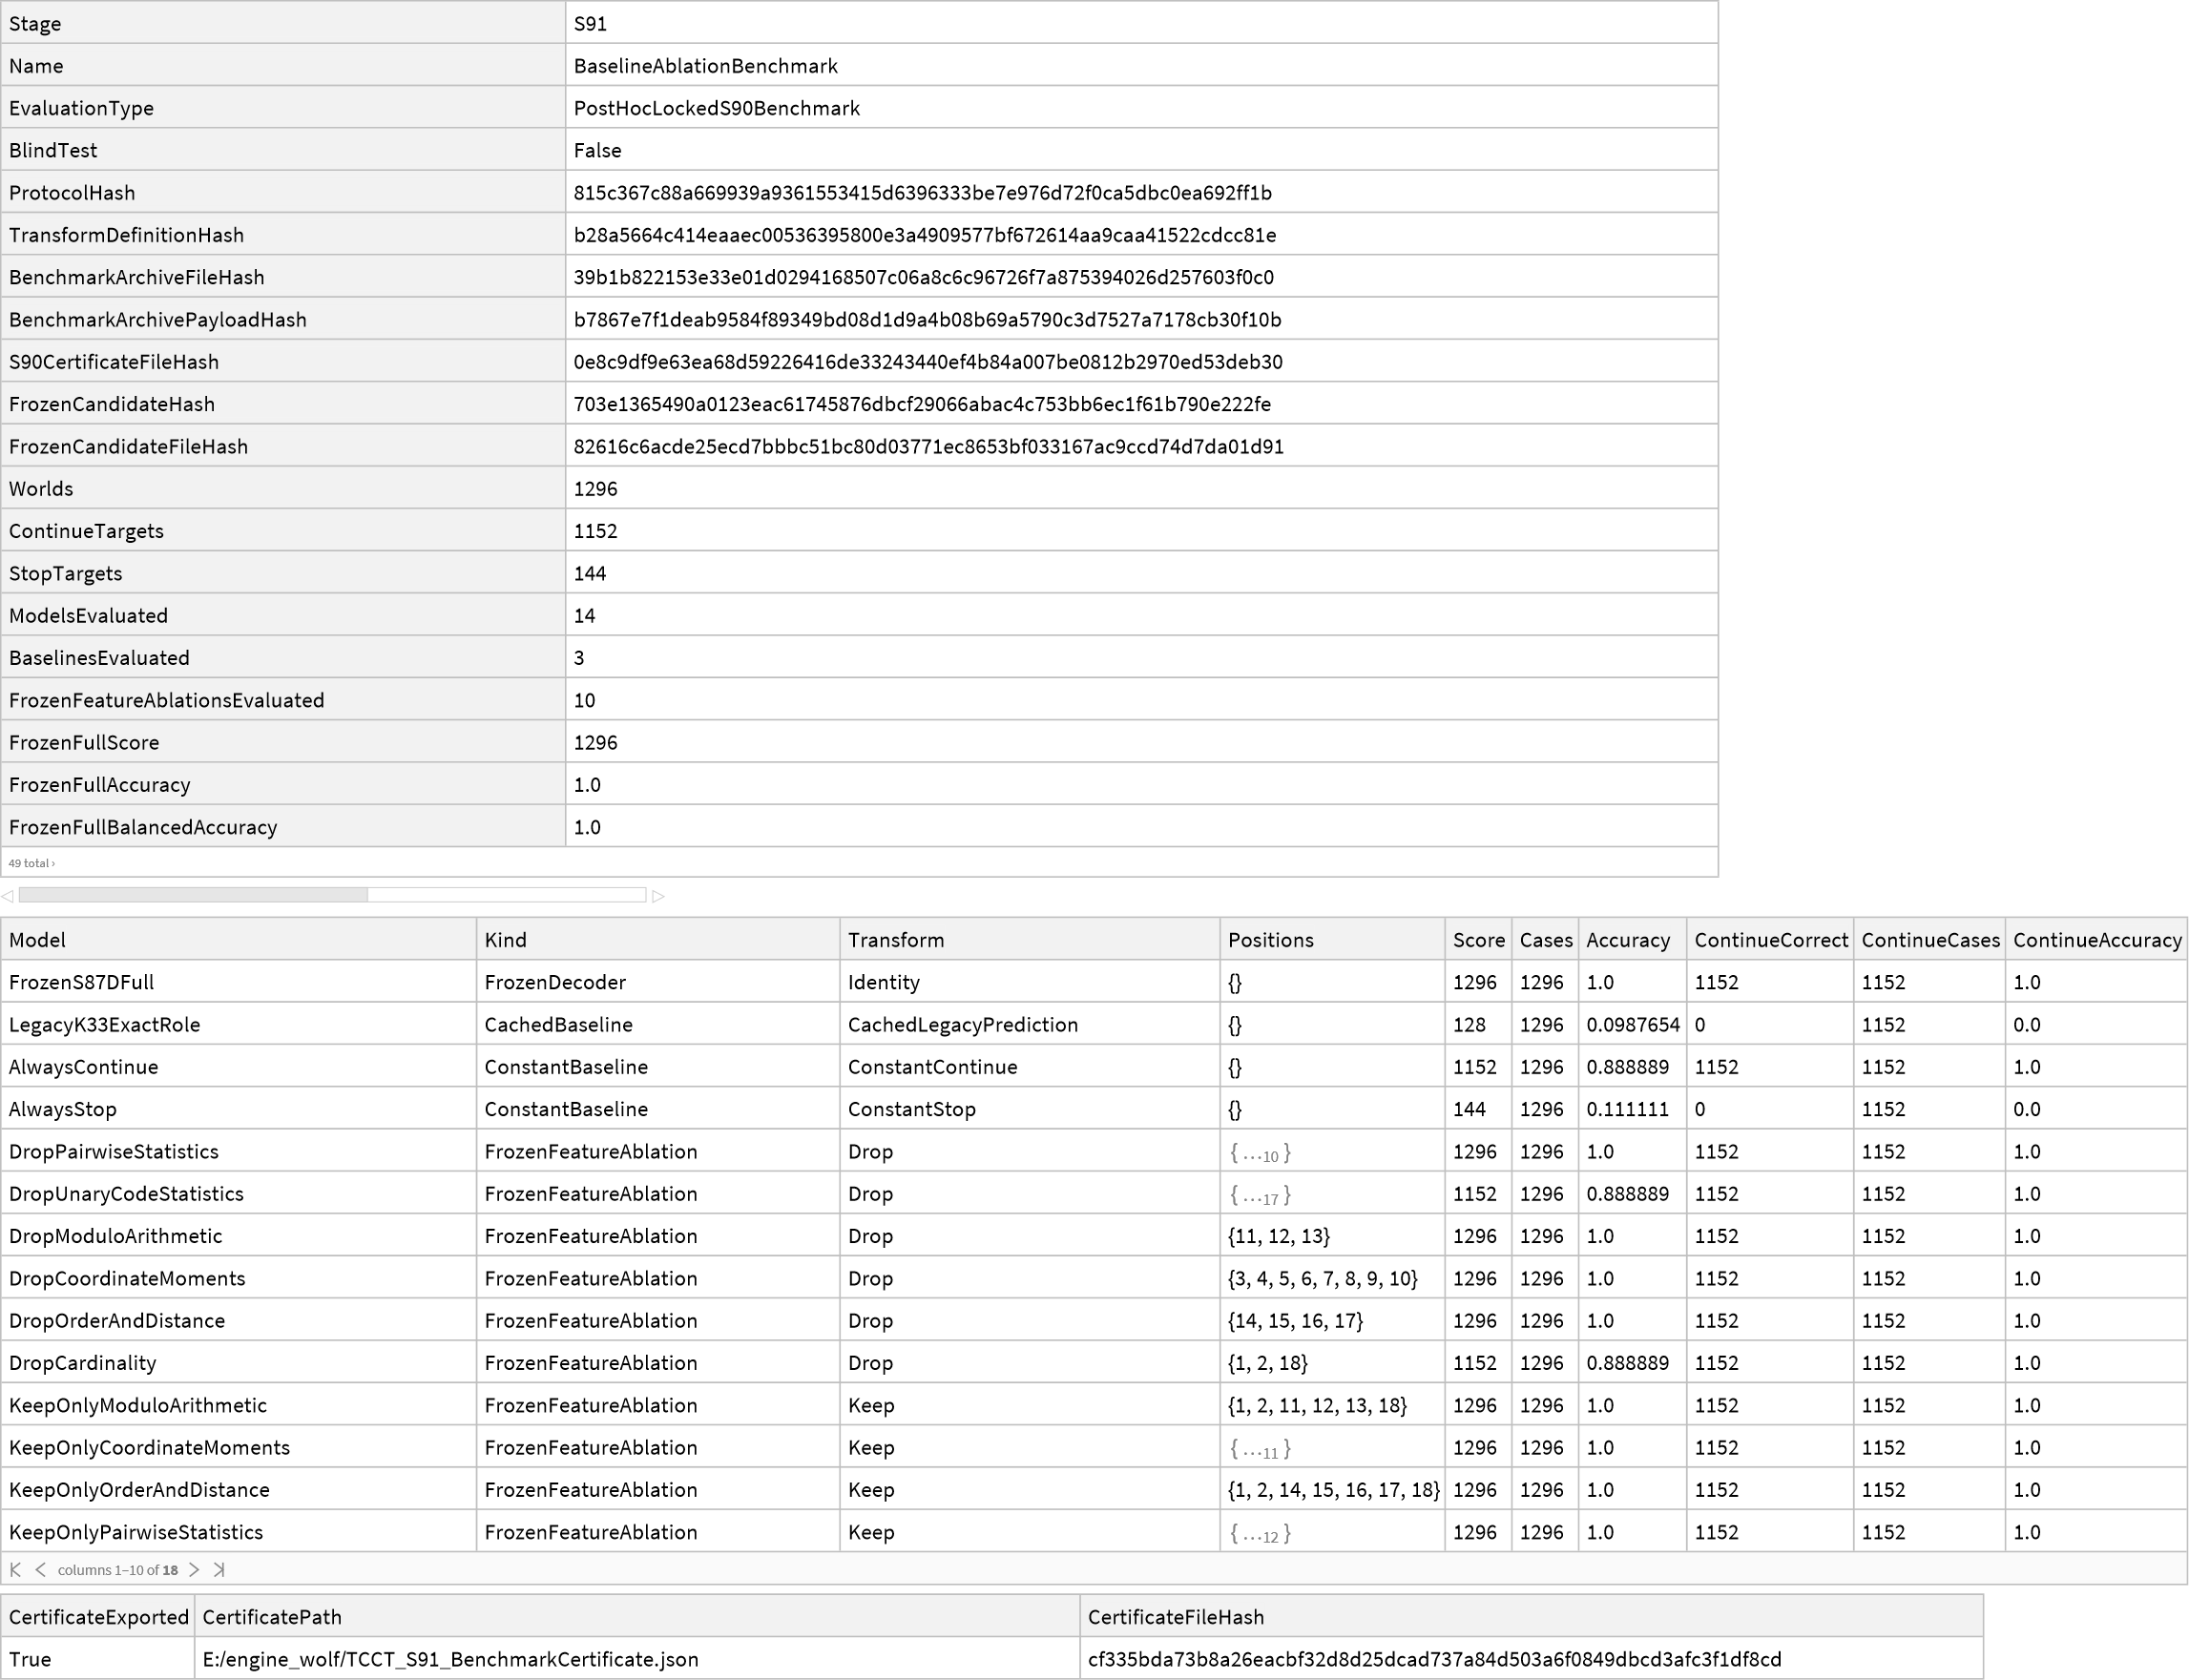

In [981]:
protocolHashAfterScoring91=Hash[Normal[protocol91],"SHA256","HexString"];
transformDefinitionHashAfterScoring91=Hash[{
DownValues[ZeroPositions91],DownValues[KeepPositions91],
DownValues[TransformVector91],Normal[modelSpecs91]},"SHA256","HexString"];
archiveFileHashAfter91=FileSHA256Hex91[archivePath91];
archiveManifestFileHashAfter91=FileSHA256Hex91[archiveManifestPath91];
decoderCandidateFileHashAfter91=FileSHA256Hex91[decoderCandidatePath91];
decoderRuntimeFileHashAfter91=FileSHA256Hex91[decoderRuntimePath91];
s90CertificateFileHashAfter91=FileSHA256Hex91[s90CertificatePath91];

allRowsValid91=And@@Map[Function[row,And[
SameQ[row["Cases"],1296],Between[row["Score"],{0,1296}],
Between[row["ContinueCorrect"],{0,1152}],Between[row["StopCorrect"],{0,144}],
SameQ[row["InvalidPredictions"],0]]],resultRows91];
fullFrozenPerfect91=And[SameQ[fullResult91["Score"],1296],
SameQ[fullResult91["ContinueCorrect"],1152],SameQ[fullResult91["StopCorrect"],144]];
degradedAblations91=Count[ablationRows91,row_/;row["Score"]<fullResult91["Score"]];
legacyResult91=SelectFirst[resultRows91,SameQ[#1["Model"],"LegacyK33ExactRole"]&];
fullOutperformsLegacy91=And[
fullResult91["Score"]>legacyResult91["Score"],
fullResult91["BalancedAccuracy"]>legacyResult91["BalancedAccuracy"]];

benchmarkValidityPassed91=And[
TrueQ[preflightPassed91],TrueQ[freshFullMatchesCachedS9091],
TrueQ[allRowsValid91],TrueQ[fullFrozenPerfect91],
SameQ[protocolHashBeforeScoring91,protocolHashAfterScoring91],
SameQ[transformDefinitionHashBeforeScoring91,transformDefinitionHashAfterScoring91],
SameQ[archiveFileHashBefore91,archiveFileHashAfter91],
SameQ[archiveManifestFileHashBefore91,archiveManifestFileHashAfter91],
SameQ[decoderCandidateFileHashBefore91,decoderCandidateFileHashAfter91],
SameQ[decoderRuntimeFileHashBefore91,decoderRuntimeFileHashAfter91],
SameQ[s90CertificateFileHashBefore91,s90CertificateFileHashAfter91]
];

benchmarkPayload91=<|
"Stage"->"S91","Name"->"BaselineAblationBenchmark",
"EvaluationType"->"PostHocLockedS90Benchmark","BlindTest"->False,
"ProtocolHash"->protocolHashAfterScoring91,
"TransformDefinitionHash"->transformDefinitionHashAfterScoring91,
"BenchmarkArchiveFileHash"->archiveFileHashAfter91,
"BenchmarkArchivePayloadHash"->archive91["ArchivePayloadHash"],
"S90CertificateFileHash"->s90CertificateFileHashAfter91,
"FrozenCandidateHash"->decoder91["CandidateHash"],
"FrozenCandidateFileHash"->decoderCandidateFileHashAfter91,
"Worlds"->Length[rows91],"ContinueTargets"->Count[targets91,"Continue"],
"StopTargets"->Count[targets91,"Stop"],"ModelsEvaluated"->Length[resultRows91],
"BaselinesEvaluated"->Length[baselineRows91],
"FrozenFeatureAblationsEvaluated"->Length[ablationRows91],
"FrozenFullScore"->fullResult91["Score"],
"FrozenFullAccuracy"->fullResult91["Accuracy"],
"FrozenFullBalancedAccuracy"->fullResult91["BalancedAccuracy"],
"LegacyScore"->legacyResult91["Score"],
"LegacyAccuracy"->legacyResult91["Accuracy"],
"LegacyBalancedAccuracy"->legacyResult91["BalancedAccuracy"],
"FullOutperformsLegacy"->fullOutperformsLegacy91,
"DegradedAblations"->degradedAblations91,
"BestAblationScore"->Max[Lookup[ablationRows91,"Score"]],
"WorstAblationScore"->Min[Lookup[ablationRows91,"Score"]],
"ModelResults"->resultRows91,
"FreshFullPredictionsMatchArchivedS90"->freshFullMatchesCachedS9091,
"BenchmarkValidityPassed"->benchmarkValidityPassed91,
"OriginalFrozenModelChanged"->False,"CoreChanged"->False,
"CanonicalizerChanged"->False,"InterventionRulesChanged"->False,
"DeduplicationMechanismChanged"->False,"UndirectedFreezeMechanismChanged"->False,
"FrozenDecoderChanged"->!SameQ[decoderCandidateFileHashBefore91,
decoderCandidateFileHashAfter91],
"S90CertificateChanged"->!SameQ[s90CertificateFileHashBefore91,
s90CertificateFileHashAfter91],
"BenchmarkArchiveChanged"->!SameQ[archiveFileHashBefore91,archiveFileHashAfter91],
"TrainingRun"->False,"CandidateSearchRun"->False,
"HyperparameterSearchRun"->False,"RetuningApplied"->False,
"AblationsRetrained"->False,"TransformUsesTargets"->False,
"MayClaimNewBlindGeneralization"->False,
"MayClaimAblationCausality"->False
|>;
benchmarkResultHash91=Hash[Normal[benchmarkPayload91],"SHA256","HexString"];
cert91=Join[benchmarkPayload91,<|
"BenchmarkResultHash"->benchmarkResultHash91,
"Outcome"->If[TrueQ[benchmarkValidityPassed91],
"S91_VALID_POSTHOC_BASELINE_ABLATION_COMPLETE",
"S91_INVALID_BENCHMARK_DO_NOT_INTERPRET"],
"SuggestedNextStage"->If[TrueQ[benchmarkValidityPassed91],
"S92_RETRAINED_ABLATIONS_AND_NEW_BLIND_HOLDOUT",
"S91R_REPAIR_BENCHMARK_HARNESS_WITHOUT_MODEL_CHANGE"]|>];
certificateExportResult91=Quiet@Check[
Export[s91CertificatePath,cert91,"RawJSON"],$Failed];
certificateExported91=And[StringQ[certificateExportResult91],
FileExistsQ[s91CertificatePath]];

Column[{
Dataset[{KeyDrop[cert91,{"ModelResults"}]}],
Dataset[resultRows91],
Dataset[{<|"CertificateExported"->certificateExported91,
"CertificatePath"->s91CertificatePath,
"CertificateFileHash"->If[certificateExported91,
FileSHA256Hex91[s91CertificatePath],"NOT_EXPORTED"]|>}]
}]